In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

In [11]:
ev2 =  pd.read_csv('../../Datasets/evaluacion2.csv')
ev2.head(3)

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.0,PC Components,Media,5.484755,0.000000,5.883322
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,No Badge,Sponsored,1,0,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,Best Seller,Organic,0,1,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598


In [74]:
ev2 =  pd.read_csv('ev2_Word2vec.csv')
ev2.head()

,product_title,product_rating,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_category,product_segment,log_original_price,log_purchased_last_month,log_total_reviews,extracted_brand
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,No Badge,Sponsored,1,0,0,0.0,PC Components,Media,5.484755,0.000000,5.883322,Owc
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,No Badge,Sponsored,1,0,0,0.0,Storage & Memory Cards,Media,3.783962,0.000000,5.624018,Owc
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,Best Seller,Organic,0,1,0,0.0,"Office Supplies, Ink & Toner",Media,3.607941,10.819798,11.523598,Tp-Link
3,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,4.6,No Badge,Organic,0,0,0,0.0,"Office Supplies, Ink & Toner",Media,3.804215,10.819798,10.986868,Tp-Link
4,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,Best Seller,Organic,0,0,0,0.0,"Audio, Sound & Recording Gear",Baja,2.355178,9.210440,11.598433,Sony


In [75]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Preparar datos
# Si quieres usar One-Hot Encoding, hazlo para todas las categóricas
categorical_cols = ['is_best_seller', 'is_sponsored', 'product_category', 
                    'product_segment']

# Aplicar One-Hot Encoding a todas las variables categóricas
ev2_encoded = pd.get_dummies(ev2, columns=categorical_cols + ['extracted_brand'], 
                            drop_first=True)

# Preparar X e y
X = ev2_encoded.drop(columns=['product_title', 'log_original_price'])
y = ev2_encoded['log_original_price']

# Verificar tipos de datos
print("Tipos de datos en X:")
print(X.dtypes.value_counts())

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo XGBoost - SIN enable_categorical porque ya usamos One-Hot
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

# Entrenar con validación temprana
print("Entrenando modelo...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100  # Para ver progreso
)

# Predicciones
y_pred = model.predict(X_test)

# Convertir de log a escala original
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred)

# Métricas
r2 = r2_score(y_test_eur, y_pred_eur)
rmse = np.sqrt(mean_squared_error(y_test_eur, y_pred_eur))
mae = np.mean(np.abs(y_test_eur - y_pred_eur))

print(f'\n=== RESULTADOS ===')
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'Rango de precios real: €{y_test_eur.min():.2f} - €{y_test_eur.max():.2f}')

# Importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 10 features más importantes:')
print(feature_importance.head(10))

# Mostrar primeras filas
print('\nPrimeras filas de X:')
print(X.head())

Tipos de datos en X:
bool       60
float64     4
int64       3
Name: count, dtype: int64
Entrenando modelo...
[0]	validation_0-rmse:1.25662
[100]	validation_0-rmse:0.50564
[200]	validation_0-rmse:0.49742
[251]	validation_0-rmse:0.49697

=== RESULTADOS ===
R² Score: 0.7683
RMSE: 207.61
MAE: 87.91
Rango de precios real: €3.98 - €4995.95

Top 10 features más importantes:
                                              feature  importance
36                               product_segment_Baja    0.388008
37                              product_segment_Media    0.111393
27                 product_category_Power & Batteries    0.055272
19       product_category_Chargers, Adapters & Cables    0.051164
29  product_category_Small Gadget Accessories (Cas...    0.047634
21                           product_category_Laptops    0.045341
18             product_category_Cameras & Photography    0.029169
28    product_category_Printers & Scanners (Hardware)    0.021033
26                     product_cate

In [30]:
categorical_cols = ['is_best_seller', 'is_sponsored', 'product_category', 
                    'product_segment']

# Aplicar One-Hot Encoding a todas las variables categóricas
ev2_encoded = pd.get_dummies(df_word2vec, columns=categorical_cols + ['extracted_brand'], 
                            drop_first=True)

ev2_encoded.filter(like='is_sponsored')

,is_sponsored_Sponsored
0,True
1,True
2,False
3,False
4,False
...,...
7712,False
7713,False
7714,False
7715,False


In [31]:
len(df_word2vec.extracted_brand.unique())

30

In [19]:
len(ev2_encoded.filter(like='extracted_brand').columns)

29

In [32]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev2_encoded)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,buy_box_availability,7717,0,int64,2
3,sustainability_tags,7717,0,int64,2
4,has_coupon,7717,0,int64,2
...,...,...,...,...,...
64,extracted_brand_Texas,7717,0,bool,2
65,extracted_brand_Tp-Link,7717,0,bool,2
66,extracted_brand_Unknown,7717,0,bool,2
67,extracted_brand_Vivo,7717,0,bool,2


In [33]:
target = 'log_original_price'

In [34]:
ev2_encoded.drop(columns=['product_title'], inplace=True)

In [35]:
X = ev2_encoded.drop(columns=[target])
y = ev2_encoded[target]
y_euro = np.expm1(y)

In [36]:
X.dtypes

product_rating                     float64
buy_box_availability                 int64
sustainability_tags                  int64
has_coupon                           int64
discount_percentage                float64
                                    ...   
extracted_brand_Texas                 bool
extracted_brand_Tp-Link               bool
extracted_brand_Unknown               bool
extracted_brand_Vivo                  bool
extracted_brand_Western Digital       bool
Length: 67, dtype: object

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")

Dimensiones de X_train: (6173, 67)
Dimensiones de X_test:  (1544, 67)


C:\Users\USER\AppData\Local\Temp\ipykernel_10704\1541016602.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])


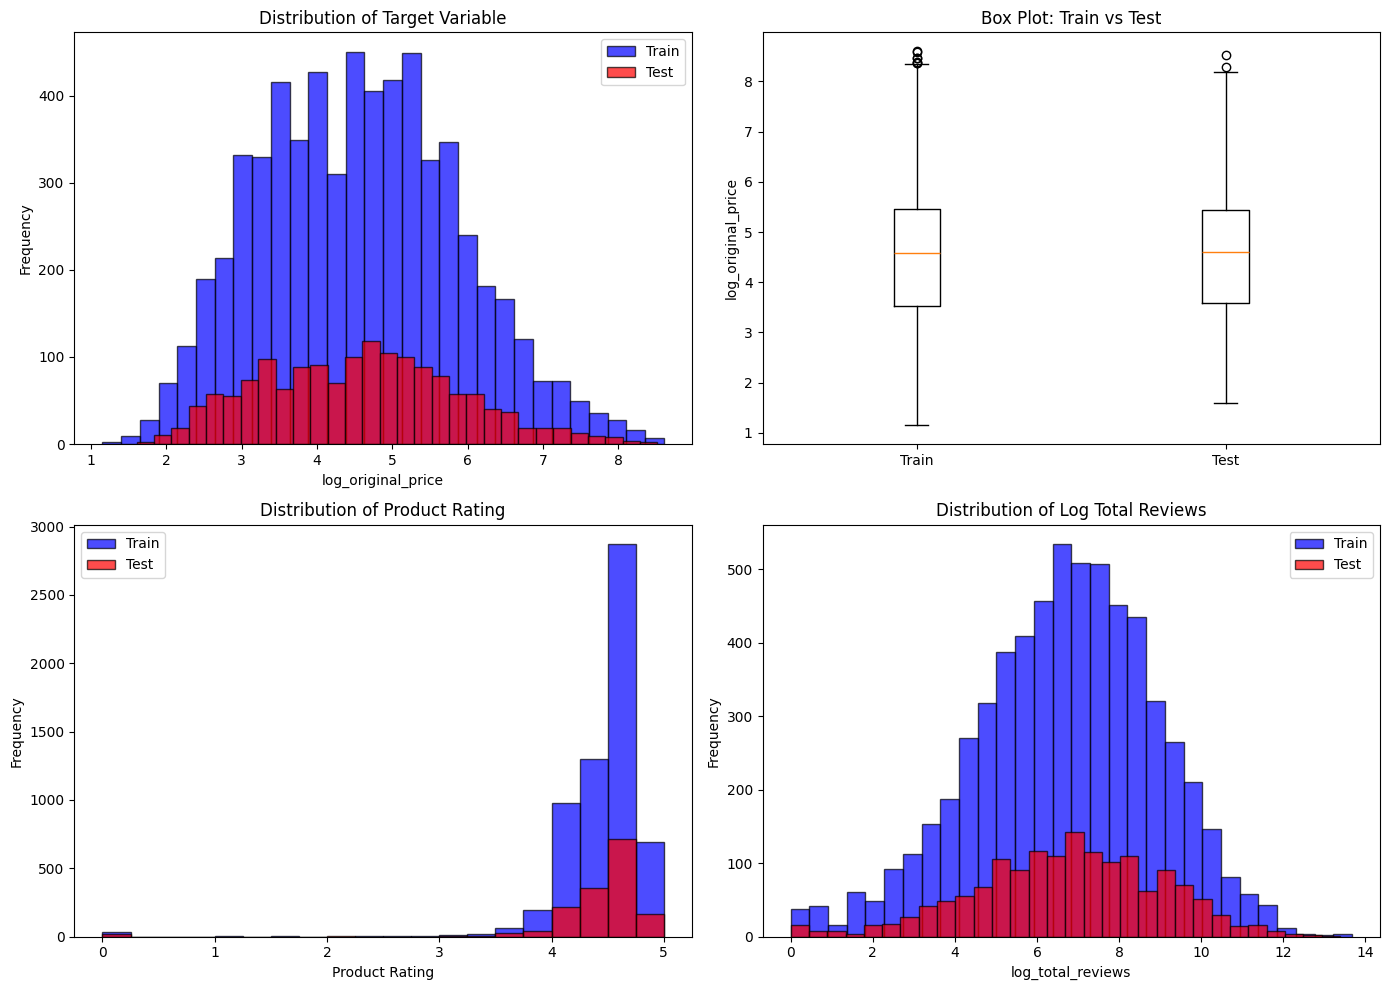

In [38]:
# Create visualizations for train and test data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of target variable
axes[0, 0].hist(y_train, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 0].hist(y_test, bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[0, 0].set_xlabel('log_original_price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Target Variable')
axes[0, 0].legend()

# 2. Box plot comparison
axes[0, 1].boxplot([y_train, y_test], labels=['Train', 'Test'])
axes[0, 1].set_ylabel('log_original_price')
axes[0, 1].set_title('Box Plot: Train vs Test')

# 3. Product rating distribution
axes[1, 0].hist(X_train['product_rating'], bins=20, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 0].hist(X_test['product_rating'], bins=20, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 0].set_xlabel('Product Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Product Rating')
axes[1, 0].legend()

# 4. Log total reviews distribution
axes[1, 1].hist(X_train['log_total_reviews'], bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 1].hist(X_test['log_total_reviews'], bins=30, alpha=0.7, label='Test', color='red', edgecolor='black')
axes[1, 1].set_xlabel('log_total_reviews')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Log Total Reviews')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [62]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from tqdm.auto import tqdm
import sys

# Instalar si no lo tienes: pip install tqdm

dtrain_reg = xgb.DMatrix(X_train, y_train)
dtest_reg = xgb.DMatrix(X_test, y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',  # GPU
    'device': 'cuda',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 42
}

# ========================================
# PRIMERA PARTE: Entrenamiento inicial con barra de progreso
# ========================================
print("🚀 Entrenamiento inicial...")

# Callback personalizado para barra de progreso
class TqdmCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds):
        self.pbar = tqdm(total=total_rounds, desc="Training", 
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
    
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        if epoch % 100 == 0:
            # Mostrar métricas cada 100 iteraciones
            train_rmse = evals_log['train']['rmse'][-1]
            val_rmse = evals_log['val']['rmse'][-1]
            self.pbar.set_postfix({'train_rmse': f'{train_rmse:.4f}', 
                                  'val_rmse': f'{val_rmse:.4f}'})
        return False
    
    def after_training(self, model):
        self.pbar.close()
        return model

evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False,  # Desactivar verbose normal
    callbacks=[TqdmCallback(3000)]
)
best_iteration = model.best_iteration
print(f"✅ Mejor iteración: {best_iteration}\n")

# ========================================
# SEGUNDA PARTE: RandomizedSearchCV con barra de progreso
# ========================================
print("🔍 Búsqueda de hiperparámetros...")

param_dist = {
    'max_depth': [3,5,6, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6,0.7, 0.8],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1,2, 3],
    'gamma': [0, 0.1, 0.2,0.3,0.4],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    device='cuda',
    enable_categorical=True,
    verbosity=0  # Silenciar XGBoost
)

# Wrapper para añadir barra de progreso a RandomizedSearchCV
from sklearn.model_selection._search import BaseSearchCV

class TqdmRandomizedSearchCV(RandomizedSearchCV):
    def fit(self, X, y=None, **fit_params):
        # Crear barra de progreso
        total_fits = self.n_iter * self.cv
        self.pbar = tqdm(total=total_fits, desc="Grid Search", 
                        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]')
        
        # Guardar el método original
        original_fit = super().fit
        
        # Wrapper del fit
        result = original_fit(X, y, **fit_params)
        self.pbar.close()
        return result
    
    def _run_search(self, evaluate_candidates):
        # Wrapper para actualizar la barra
        def evaluate_with_progress(candidates):
            for candidate in candidates:
                self.pbar.update(self.cv)
                yield candidate
        
        super()._run_search(lambda candidates: evaluate_candidates(evaluate_with_progress(candidates)))

random_search = TqdmRandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0,  # Silenciar verbose normal
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros encontrados:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Mejor score: {-random_search.best_score_:.4f}")

🚀 Entrenamiento inicial...


Training:   0%|          | 0/3000 [00:00<?]

c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\xgboost\callback.py:386: UserWarning: [20:27:43] WARNING: C:\miniconda3\conda-bld\xgboost-split_1764761400759\work\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


✅ Mejor iteración: 315

🔍 Búsqueda de hiperparámetros...


Grid Search:   0%|          | 0/250 [00:00<?]


✅ Mejores parámetros encontrados:
   subsample: 0.6
   reg_lambda: 1
   reg_alpha: 0.1
   min_child_weight: 1
   max_depth: 7
   learning_rate: 0.05
   gamma: 0
   colsample_bytree: 0.8

📊 Mejor score: 0.2734


In [63]:
best_model = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")

Mejores parámetros: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}


In [70]:
model_2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

# Entrenar con validación temprana
print("Entrenando modelo...")
model_2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=0  # Para ver progreso
)
# Predicciones
y_pred = model_2.predict(X_test)

# Convertir de log a escala original
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred)

# Métricas
r2 = r2_score(y_test_eur, y_pred_eur)
rmse = np.sqrt(mean_squared_error(y_test_eur, y_pred_eur))
mae = np.mean(np.abs(y_test_eur - y_pred_eur))

print(f'\n=== RESULTADOS ===')
print(f'R² Score: {r2:.4f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'Rango de precios real: €{y_test_eur.min():.2f} - €{y_test_eur.max():.2f}')

# Importancia de features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_2.feature_importances_
}).sort_values('importance', ascending=False)

print('\nTop 10 features más importantes:')
print(feature_importance.head(10))

# Mostrar primeras filas
print('\nPrimeras filas de X:')
print(X.head())

Entrenando modelo...

=== RESULTADOS ===
R² Score: 0.7683
RMSE: 207.61
MAE: 87.91
Rango de precios real: €3.98 - €4995.95

Top 10 features más importantes:
                                              feature  importance
36                               product_segment_Baja    0.388008
37                              product_segment_Media    0.111393
27                 product_category_Power & Batteries    0.055272
19       product_category_Chargers, Adapters & Cables    0.051164
29  product_category_Small Gadget Accessories (Cas...    0.047634
21                           product_category_Laptops    0.045341
18             product_category_Cameras & Photography    0.029169
28    product_category_Printers & Scanners (Hardware)    0.021033
26                     product_category_PC Components    0.020204
5                            log_purchased_last_month    0.019018

Primeras filas de X:
   product_rating  buy_box_availability  sustainability_tags  has_coupon  \
0             4.4   

In [77]:
X_test

,product_rating,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,log_purchased_last_month,log_total_reviews,is_best_seller_Best Seller,is_best_seller_Ends in,is_best_seller_Limited time deal,...,extracted_brand_Samsung,extracted_brand_Scotch,extracted_brand_Seagate,extracted_brand_Sharpie,extracted_brand_Sony,extracted_brand_Texas,extracted_brand_Tp-Link,extracted_brand_Unknown,extracted_brand_Vivo,extracted_brand_Western Digital
2168,3.8,0,0,0,0.00,0.000000,3.218876,False,False,False,...,False,False,False,False,False,False,False,False,False,False
472,4.7,1,0,0,0.16,8.006701,8.331586,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4159,4.4,1,0,0,0.00,5.707110,7.157735,False,False,False,...,False,False,False,False,False,False,False,False,False,False
676,4.5,0,0,0,0.00,8.294300,9.684709,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6659,4.3,1,0,0,0.00,0.000000,5.823046,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1732,4.7,0,0,0,0.00,6.685861,7.694393,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1436,4.7,1,0,0,0.36,8.294300,9.041922,True,False,False,...,False,True,False,False,False,False,False,False,False,False
5879,4.5,1,0,0,0.00,4.615121,5.288267,False,False,False,...,False,False,False,False,False,False,True,False,False,False
5538,4.6,1,0,1,0.19,5.707110,6.840547,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [76]:
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_error

y_pred = best_model.predict(X_test)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred)

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test.columns if 'segment' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)


Segmento product_segment_Baja:
   - Error en Euros (MAE): 10.26 €
   - Error en % (MAPE):    40.51 %
--------------------
Segmento product_segment_Media:
   - Error en Euros (MAE): 85.27 €
   - Error en % (MAPE):    47.93 %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      89.63 €
MedAE (Error Típico):   29.90 €
RMSE (Error Penalizado): 209.80 €
MAPE (Error Porcentual): 44.73 %
R2 Score (Calidad):      0.7633


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='weight', ax=axes[0])
axes[0].set_title('WEIGHT: Frecuencia de uso')

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='gain', ax=axes[1])
axes[1].set_title('GAIN: Mejora en predicción (RECOMENDADO)')

xgb.plot_importance(best_model, max_num_features=10, 
                    importance_type='cover', ax=axes[2])
axes[2].set_title('COVER: Muestras afectadas')

plt.tight_layout()
plt.show()